<a href="https://colab.research.google.com/github/raffi326/mesin_learning/blob/main/Simple_Linear_Regression_(11_12).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Load datasets

In [8]:
#Nama dataframe kita adalah df yang berisi data dari data.csv
#Hanya menggunakan kolom 'horsepower' dan 'price'
df = pd.read_csv('data.csv', usecols=['horsepower', 'price'], header=None, names=['horsepower', 'price'])

### Sneak peak data

In [9]:
#Melihat 5 baris teratas dari data
#Independent variabel(x) adalah horsepower
#Dependent variabel(y) adalah price
df.head()

,horsepower,price
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4


In [10]:
#Mengetahui jumlah kolom dan baris dari data
#Data kita mempunya 2 kolom dengan 200 baris
df.shape

(63, 2)

In [11]:
#Melihat informasi data kita mulai dari jumlah data, tipe data, memory yang digunakan dll.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   horsepower  63 non-null     int64  
 1   price       63 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [12]:
#Melihat statistical description dari data mulai dari mean, kuartil, standard deviation dll
df.describe()

,horsepower,price
count,63.000000,63.000000
mean,22.904762,98.187302
std,23.351946,87.327553
min,0.000000,0.000000
25%,7.500000,38.850000
50%,14.000000,73.400000
75%,29.000000,140.000000
max,124.000000,422.200000


### Handling Missing Values

In [13]:
#Mencari dan menangani missing values
#Ternyata data kita tidak ada missing values
df.isnull().sum()

,0
horsepower,0
price,0


### Exploratory Data Analysis (EDA)

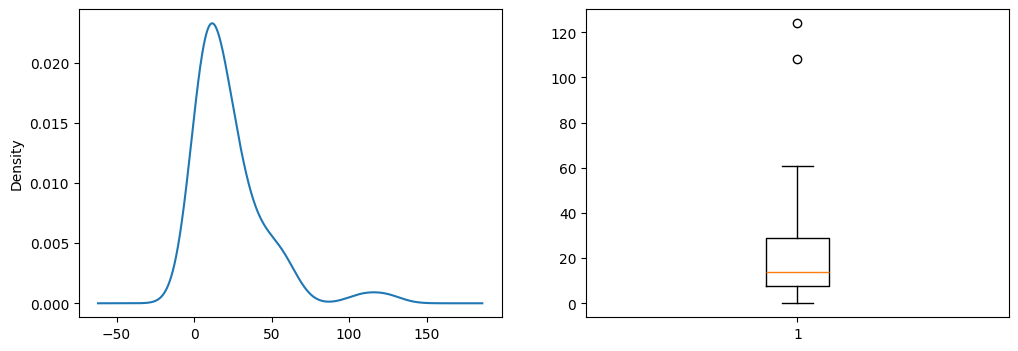

In [14]:
#Univariate analysis horsepower
#Melihat distribusi dari horsepower
f = plt.figure(figsize=(12,4))

f.add_subplot(1,2,1)
df['horsepower'].plot(kind='kde')

f.add_subplot(1,2,2)
plt.boxplot(df['horsepower'])
plt.show()

- Dapat dilihat bahwa density dari horsepower paling tinggi di nilai 100.
- Distribusinya hampir mirip dengan distribusi normal namun persebaran data kurang merata (memiliki standard deviasi yang tinggi).

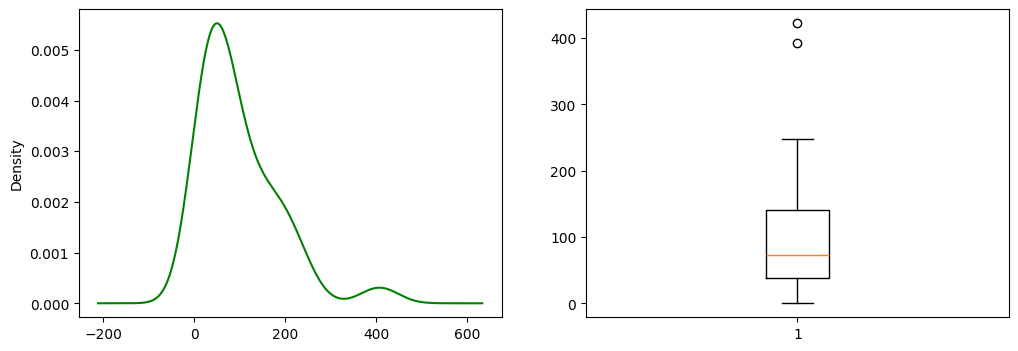

In [15]:
#Univariate analysis price
#Melihat distribusi dari price
f = plt.figure(figsize=(12,4))

f.add_subplot(1,2,1)
df['price'].plot(kind='kde', c='g')

f.add_subplot(1,2,2)
plt.boxplot(df['price'])
plt.show()

- Density dari price paling tinggi di nilai 10000.
- Distribusinya hampir mirip dengan distribusi normal namun persebaran data kurang merata (memiliki standard deviasi yang tinggi).

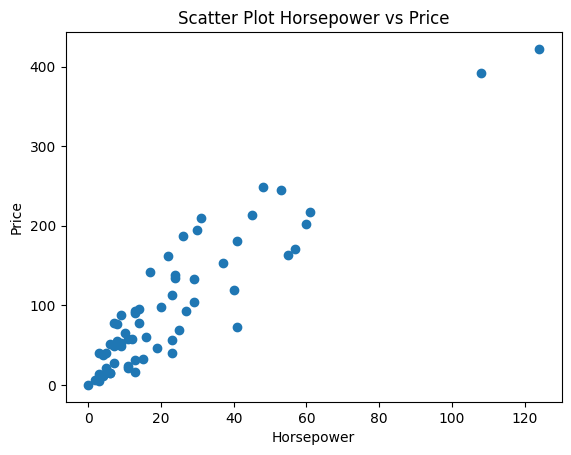

In [16]:
#Bivariate analysis horsepower dan price
#Menggunakan scatter plot
plt.scatter(df['horsepower'], df['price'])
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Scatter Plot Horsepower vs Price')
plt.show()

- Dari scatter plot dapat dilihat bahwa data memiliki korelasi positif yang cukup signifikan.
- Hal ini berarti dengan bertambahnya nilai dari horsepower maka nilai price pun akan bertambah

In [17]:
#Mengetahui nilai korelasi dari horsepower dan price
#Nilai korelasinya adalah 0.81 termasuk kategori sangat tinggi
df.corr()

,horsepower,price
horsepower,1.000000,0.912878
price,0.912878,1.000000


- Setelah kita tahu tentang karakteristik data kita, bisa dilanjutkan ke tahap modelling

### Modelling

In [18]:
#Recall data kita
df.head()

,horsepower,price
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4


In [19]:
#Pertama, buat variabel x dan y
x = df['horsepower'].values.reshape(-1,1)
y = df['price'].values.reshape(-1,1)

In [20]:
#Kedua, kita split data kita menjadi training and testing dengan porsi 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [21]:
#Ketiga, kita bikin object linear regresi
lin_reg = LinearRegression()

In [22]:
#Keempat, train the model menggunakan training data yang sudah displit
lin_reg.fit(x_train, y_train)

LinearRegression()

In [23]:
#Kelima, cari tau nilai slope/koefisien (m) dan intercept (b)
print(lin_reg.coef_)
print(lin_reg.intercept_)

[[3.40379612]]
[21.77134863]


- dari nilai m dan b diatas, kalau dimasukan ke dalam rumus menjadi:
Y = 164.73x - 3903.39

In [24]:
#Keenam, kita cari tahu accuracy score dari model kita menggunakan testing data yang sudah displit
lin_reg.score(x_test, y_test)

0.7040398059333031

- Model kita mendapatkan accuracy score sebesar 78.68%

Text(0.5, 1.0, 'Plot Horsepower vs Price')

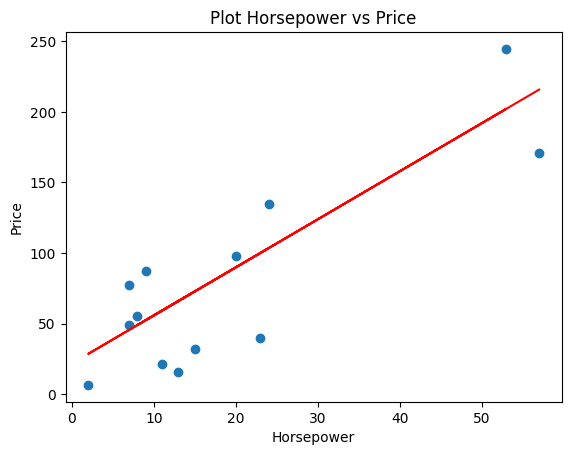

In [25]:
#Ketujuh, visualisasi aktual vs prediksi menggunakan data testing
#Garis merah merupakan garis regresi dari persamaan yang kita dapat tadi
y_prediksi = lin_reg.predict(x_test)
plt.scatter(x_test, y_test)
plt.plot(x_test, y_prediksi, c='r')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Plot Horsepower vs Price')

### Prediction
- Yuk kita prediksi harga mobil ketika memiliki horsepower 100, 150, dan 200

In [26]:
#Prediksi harga mobil dengan horsepower 100
lin_reg.predict([[100]])

array([[362.15096072]])

In [27]:
#Prediksi harga mobil dengan horsepower 150
lin_reg.predict([[150]])

array([[532.34076676]])

In [28]:
#Prediksi harga mobil dengan horsepower 200
lin_reg.predict([[200]])

array([[702.53057281]])

- dengan melihat prediksi harga diatas, didapatkan bahwa hipotesis awal kita memang benar yaitu mobil dengan Horsepower 200 memiliki harga yang lebih mahal daripada yang lain!

In [29]:
# Download the data
!wget https://raw.githubusercontent.com/jbrownlee/Datasets/master/auto-insurance.csv -O data.csv

--2025-07-08 16:12:58--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/auto-insurance.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 495 [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]     495  --.-KB/s    in 0s      

2025-07-08 16:12:58 (24.5 MB/s) - ‘data.csv’ saved [495/495]

